# Rural Theatre Reviews Analytics

The purpose of this project is to use natural language processing (NLP), sentiment analysis, topic modeling, and theme comparison to answer the question:


#### What factors most influence customer satisfaction at rural performing arts venues?

Additional thinking questions:
- Are visitors discussing the performance itself or the broader tourism experience?
- What operational issues most affect customer ratings?
- Do tourists value different aspects of the experience than local patrons? <br>
<br>
Tools: Python, pandas, numpy, NLTK, matplotlib, seaborn <br>
<br>
Data: The dataset consists of 650+ publicly available reviews from five theaters in a rural, tourism-based market. While the findings may not generalize to large urban performing centers, they provide insight into customer experiences and satisfaction drivers within comparable rural arts organizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

plt.style.use('ggplot')

df = pd.read_csv("Reviews Scraping - Data.csv")

df.head()

,Reviewer Name,Review Text,Published Date,Stars Given,Review URL,Owner Response Text,Venue name
0,Troy Everett,NaN,2026-02-02T17:58:49.434Z,5,https://www.google.com/maps/contrib/1007492457...,NaN,Door Shakespeare Day Time Office and Gift Shop
1,Zarata Tapsoba,Friendly staff❤️Great show !!❤️,2025-08-13T21:44:29.416Z,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop
2,Luther Snow,Best theater in Door County. Among the best S...,2025-08-08T21:54:25.906Z,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop
3,nancy mcgrath,Absolutely wonderful production! Our family me...,2025-07-29T04:33:19.793Z,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop
4,Jade D,My favorite part of Door County!!!! Absolutely...,2025-07-05T23:51:56.945Z,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop


### Preproduction EDA

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Reviewer Name        655 non-null    str  
 1   Review Text          446 non-null    str  
 2   Published Date       655 non-null    str  
 3   Stars Given          655 non-null    int64
 4   Review URL           655 non-null    str  
 5   Owner Response Text  394 non-null    str  
 6   Venue name           655 non-null    str  
dtypes: int64(1), str(6)
memory usage: 35.9 KB


In [3]:
df.isnull().sum()

Reviewer Name            0
Review Text            209
Published Date           0
Stars Given              0
Review URL               0
Owner Response Text    261
Venue name               0
dtype: int64

Text(0.5, 0, 'Review Stars')

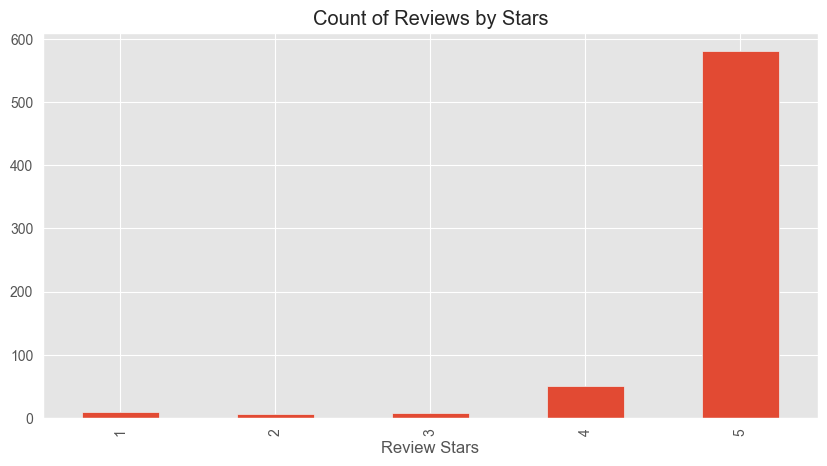

In [4]:
ax = (df['Stars Given'].value_counts().sort_index()
      .plot(kind='bar',
            title='Count of Reviews by Stars',
            figsize=(10,5)))
ax.set_xlabel('Review Stars')

In [5]:
percentages = df['Stars Given'].value_counts(normalize=True).sort_index() * 100
percentages

Stars Given
1     1.526718
2     0.916031
3     1.221374
4     7.786260
5    88.549618
Name: proportion, dtype: float64

Nearly 90% of the reviews are five stars, and over 95% are "positive" (4 or 5 stars). This shows...

In [6]:
df['word_count'] = df['Review Text'].str.split().str.len()
df['word_count'].describe()

count    446.000000
mean      25.764574
std       32.217947
min        1.000000
25%        7.000000
50%       14.000000
75%       32.750000
max      308.000000
Name: word_count, dtype: float64

### Data Cleaning

In [7]:
# feature name normalization
df = df.rename(columns={
    "Reviewer Name": "reviewer_name",
    "Review Text": "review_text",
    "Published Date": "published_date",
    "Stars Given": "stars_given",
    "Review URL": "review_url",
    "Owner Response Text": "owner_response_text",
    "Venue name": "venue_name"
})

# use only reviews with text
df = df.dropna(subset=['review_text'])
df = df.drop_duplicates()
df = df[df['review_text'].str.strip() != ""]

# remove very short reviews
df = df[df['word_count'] >= 3]

df.shape

(420, 8)

In [8]:
import re
# create light cleaned text (for sentiment analysis) and full cleaned text (for topic modeling)
def light_clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def full_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['light_clean_review'] = df['review_text'].apply(light_clean_text)
df['full_clean_review'] = df['review_text'].apply(full_clean_text)

# type conversion to datetime
df['published_date'] = pd.to_datetime(df['published_date']).dt.date

df.head()

,reviewer_name,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,Zarata Tapsoba,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,Luther Snow,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,nancy mcgrath,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,Jade D,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,Paul Adamczyk,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


### NLTK